# A practice example
Date: 13 Feb 2026 (by Vikram Khaire)

### Class 16 notes
*  Class 13 was theory of interpolation
*  Class 14 was theory of integration
*  Class 15 notes was just the copy of the workout



### Problem:
Two stars of masses $m_1$ and $m_2$ interact only through their mutual gravitational attraction. Simulate the motion of the two stars in two dimensions by updating their positions and velocities in small time steps. 

For such a simulation, calculate the gravitational force acting on each star due to the other. Then, starting from given initial positions and velocities, compute the accelerations of the two stars and update their velocities and positions at each time step using a fixed time step $\Delta t$. Perform a simulation for a large number of such steps. Using the Python code you wrote:

1) Plot the trajectories of both stars in the $x$--$y$ plane.

2) At each time step, compute the position of the center of mass of the system and plot the trajectories in the center-of-mass reference frame.  
What do you observe about the motion in this frame?

3) Repeat the simulation for different values of the mass ratio $m_1/m_2$ while keeping the initial separation fixed.  
Describe how the shapes of the trajectories change as the mass ratio is varied.

* Hint\
You may simplify the problem by working in dimensionless units with $G = 1$ and $m_1 = 1$.  
Choose initial positions and velocities in consistent units so that the motion remains bounded. 

In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# -----------------------------------------------------------
# Two-body gravitational interaction (2D)
# Using explicit Euler time integration
# -----------------------------------------------------------

# Gravitational constant (scaled units)
G = 1.0

# -----------------------------------------------------------
# Masses of the two particles
# -----------------------------------------------------------
m1 = 1.0
m2 = 0.5

# -----------------------------------------------------------
# Initial positions (x, y) of the two particles
# -----------------------------------------------------------
x1 = 0.0
y1 = 0.0

x2 = 0.1
y2 = 0.0

# -----------------------------------------------------------
# Initial velocities (vx, vy)
# -----------------------------------------------------------
v1x = 0.0
v1y = 0.0

v2x = 0.0
v2y = 0.4

# -----------------------------------------------------------
# Time step and number of integration steps
# dt must be small for stability in Euler method
# -----------------------------------------------------------
dt = 0.0000001
steps = 800000

# -----------------------------------------------------------
# Lists to store trajectories for later plotting
# -----------------------------------------------------------
x1_traj = []
y1_traj = []
x2_traj = []
y2_traj = []

# Center-of-mass trajectory
xcom_traj = []
ycom_traj = []

# -----------------------------------------------------------
# Time evolution loop
# -----------------------------------------------------------
for i in range(steps):

    # -------------------------------------------------------
    # Compute separation vector between the two particles
    # -------------------------------------------------------
    dx = x2 - x1
    dy = y2 - y1

    # Distance between particles
    r = (dx**2 + dy**2)**0.5

    # r^3 appears in gravitational force expression
    r3 = r**3

    # -------------------------------------------------------
    # Gravitational force components
    # F = G m1 m2 r_hat / r^2
    # which becomes G m1 m2 (dx, dy) / r^3
    # -------------------------------------------------------
    Fx = G * m1 * m2 * dx / r3
    Fy = G * m1 * m2 * dy / r3

    # -------------------------------------------------------
    # Accelerations from Newton's second law
    # a = F / m
    # Note: forces are equal and opposite
    # -------------------------------------------------------
    a1x = Fx / m1
    a1y = Fy / m1

    a2x = -Fx / m2
    a2y = -Fy / m2

    # -------------------------------------------------------
    # Update velocities (Explicit Euler step)
    # v(t + dt) = v(t) + a(t) dt
    # -------------------------------------------------------
    v1x = v1x + a1x * dt
    v1y = v1y + a1y * dt

    v2x = v2x + a2x * dt
    v2y = v2y + a2y * dt

    # -------------------------------------------------------
    # Update positions (Explicit Euler step)
    # x(t + dt) = x(t) + v(t) dt
    # -------------------------------------------------------
    x1 = x1 + v1x * dt
    y1 = y1 + v1y * dt

    x2 = x2 + v2x * dt
    y2 = y2 + v2y * dt

    # -------------------------------------------------------
    # Compute center-of-mass position
    # -------------------------------------------------------
    xcom = (m1 * x1 + m2 * x2) / (m1 + m2)
    ycom = (m1 * y1 + m2 * y2) / (m1 + m2)

    # -------------------------------------------------------
    # Store trajectories for analysis and plotting
    # -------------------------------------------------------
    x1_traj.append(x1)
    y1_traj.append(y1)

    x2_traj.append(x2)
    y2_traj.append(y2)

    xcom_traj.append(xcom)
    ycom_traj.append(ycom)

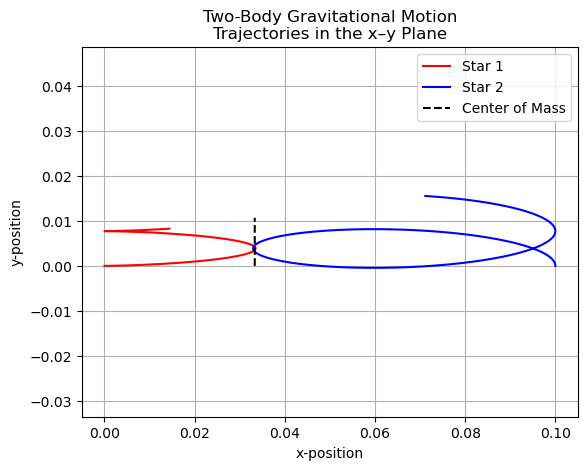

In [3]:
# -----------------------------------------------------------
# Plot trajectories of the two stars and the center of mass
# -----------------------------------------------------------

# Plot trajectory of star 1
plt.plot(x1_traj, y1_traj, label='Star 1', color = 'red')

# Plot trajectory of star 2
plt.plot(x2_traj, y2_traj, label='Star 2', color = 'blue')

# Plot center-of-mass trajectory (dashed black line)
plt.plot(xcom_traj, ycom_traj, linestyle='--', color='k', label='Center of Mass')

# Add axis labels with physical meaning
plt.xlabel('x-position')
plt.ylabel('y-position')

# Add informative title
plt.title('Two-Body Gravitational Motion\nTrajectories in the x–y Plane')

# Ensure equal scaling on both axes (important for orbits)
plt.axis('equal')

# Show legend
plt.legend()

# Optional: Add grid for clarity
plt.grid(True)

# Display the plot
plt.show()

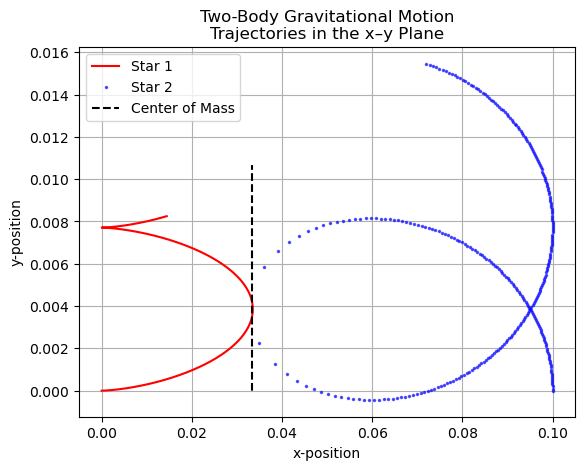

In [4]:
# -----------------------------------------------------------
# Plot the trajectory to see the speed of star 2 
# -----------------------------------------------------------

# Plot trajectory of star 1
plt.plot(x1_traj, y1_traj, label='Star 1', color = 'red')

# Plot trajectory of star 2
plt.plot(x2_traj[::2500], y2_traj[::2500], label='Star 2', color = 'blue', markersize =3,  marker = '.', alpha = 0.6, linestyle = '')

# Plot center-of-mass trajectory (dashed black line)
plt.plot(xcom_traj, ycom_traj, linestyle='--', color='k', label='Center of Mass')

# Add axis labels with physical meaning
plt.xlabel('x-position')
plt.ylabel('y-position')

# Add informative title
plt.title('Two-Body Gravitational Motion\nTrajectories in the x–y Plane')

# Ensure equal scaling on both axes (important for orbits)
#plt.axis('equal') -- commented out 

# Show legend
plt.legend()

# Optional: Add grid for clarity
plt.grid(True)

# Display the plot
plt.show()

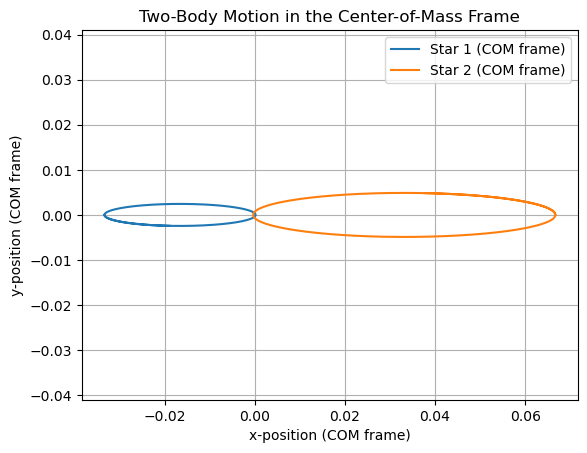

In [5]:
# -----------------------------------------------------------
# Transform positions into the Center-of-Mass (COM) frame
# -----------------------------------------------------------
# In the COM frame, we subtract the COM position from each
# star's position at every time step.
# This allows us to study the relative motion cleanly.

# Convert lists to NumPy arrays for vectorized subtraction
x1com = np.array(x1_traj) - np.array(xcom_traj)
y1com = np.array(y1_traj) - np.array(ycom_traj)

x2com = np.array(x2_traj) - np.array(xcom_traj)
y2com = np.array(y2_traj) - np.array(ycom_traj)

# -----------------------------------------------------------
# Plot motion in the Center-of-Mass frame
# -----------------------------------------------------------

# Plot star 1 trajectory in COM frame
plt.plot(x1com, y1com, label='Star 1 (COM frame)')

# Plot star 2 trajectory in COM frame
plt.plot(x2com, y2com, label='Star 2 (COM frame)')

# Label axes
plt.xlabel('x-position (COM frame)')
plt.ylabel('y-position (COM frame)')

# Add informative title
plt.title('Two-Body Motion in the Center-of-Mass Frame')

# Equal axis scaling is essential for correct orbital shape
plt.axis('equal')

# Add grid for clarity
plt.grid(True)

# Add legend
plt.legend()

# Show the plot
plt.show()

In [6]:
# notes below

## Important Physical and Numerical Notes

### 1. Conservation Laws
In an ideal gravitational system:
- Total momentum is conserved
- Center of mass should remain fixed --  in the example above it is supposed to drift (verify by calculating the velocity of the center of mass)
- Total energy should be conserved

You should check whether your numerical method respects these.

---

### 2. Limitations of Explicit Euler

The Euler method:
- Does **not conserve energy**
- May cause spiraling orbits
- Requires very small time steps for stability

For better long-term stability, methods such as:
- Velocity-Verlet
- Runge-Kutta (RK4)

are preferred.

---

### 3. Numerical Instability Warning

If particles get very close:
$r \to 0 $
the force becomes very large, which may cause numerical blow-up.

In more advanced simulations, a small softening parameter $\epsilon$ is introduced:

$
r^3 \rightarrow (r^2 + \epsilon^2)^{3/2} 
    $



## Think

Why does a tiny numerical error grow in long gravitational simulations?

(Hint: Think about energy conservation and accumulation of truncation error.)

In [7]:
# Homework -- if you are interested

# Two-Body Gravitational Simulation: Things to Explore

Now that you have simulated the motion of two stars interacting through gravity, don’t stop at just plotting the orbit. Use your code as a laboratory. Change parameters. Break symmetry. Measure carefully. Discover the laws yourself.

---

## 1) Fix the Center of Mass (COM)

Try adjusting the **initial velocities** so that the total momentum of the system is zero:

$ m_1 \vec{v}_1 + m_2 \vec{v}_2 = 0$

If this condition is satisfied:

- The **center of mass should remain stationary**.
- Both stars should orbit around a fixed COM.

### What to Observe

- Does the COM stay perfectly fixed?
- If it slowly drifts, that is **numerical error accumulation**.
- Reduce the timestep and compare the drift.

This experiment teaches you:
- Conservation of momentum  
- Sensitivity to timestep  
- Stability of numerical integration  

---

## 2) Vary Separation and Verify Kepler’s Third Law

### (a) Change the Initial Separation

- Increase or decrease the distance between the stars.
- Measure the orbital period \(T\).
- Check whether:

$T^2 \propto a^3$

For circular orbits, \(a\) is the separation.  
For elliptical orbits, \(a\) is the **semi-major axis**.


### (b) Change the Masses

Now vary \(m_1\) and \(m_2\).

Theory predicts:

$T^2 = \frac{4\pi^2}{G(m_1 + m_2)} a^3$

Investigate:

- Does the period depend on the **total mass** $(m_1 + m_2)$?
- Does it depend on the **mass ratio**, or only on the sum?
- How does changing the mass ratio affect the motion of each star about the COM?


### (c) Generalize to Elliptical Orbits

Modify the initial velocity slightly to create **elliptical motion**.

Then:

- Measure the semi-major axis \(a\).
- Verify that Kepler’s Third Law still holds with \(a\).
- Explore how the constant of proportionality changes with total mass.

---

## 3) Verify Kepler’s Second Law

Plot the **speed as a function of time** or examine velocity along the orbit.

Observe:

- Maximum speed near periapsis  
- Minimum speed near apoapsis  

This is a consequence of **angular momentum conservation**.

For a deeper test:

- Compute the area swept in equal time intervals.
- Check whether those areas are approximately equal.

This confirms:

$\text{Equal areas in equal times}$

---

## What You Are Really Doing

- Testing conservation laws  
- Studying numerical error  
- Deriving Kepler’s laws from Newton’s gravity  
- Turning a simple simulation into a physics experiment  

You are not just running code — you are rebuilding celestial mechanics from scratch.